[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/21_2_metriques_regression.ipynb)



# Les métriques de régression

Le notebook 21 mesurait la qualité d'un modèle avec `score`. Mais qu'est-ce que ce
chiffre, au juste ? Et existe-t-il de meilleures façons de mesurer une erreur ?

Une régression prédit un nombre. L'erreur est l'écart entre le prédit et le
réel. Il y a plusieurs façons de résumer ces écarts en un seul chiffre MAE, MSE,
RMSE, R²  et le choix n'est pas neutre : chacune raconte une histoire
différente, surtout en présence de valeurs aberrantes.

## Le plan

| Section | La métrique |
|---|---|
| 1 | MAE et MSE : la différence fondamentale |
| 2 | Pourquoi la MSE punit plus fort |
| 3 | RMSE : revenir à l'échelle des données |
| 4 | Le piège des valeurs aberrantes |
| 5 | Le R² : le coefficient de détermination |
| 6 | Les métriques dans la validation croisée |

## Deux pièges annoncés

Dans `cross_val_score`, l'erreur s'écrit `neg_mean_squared_error` avec un
« neg » parce que sklearn maximise toujours. Déroutant au premier abord.

Et `accuracy` ne s'utilise jamais en régression : c'est une métrique de
classification.

Prérequis : le notebook 20.

## 1. MAE et MSE : la différence fondamentale

Partons du cas le plus simple : une seule prédiction, une seule vraie valeur.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
y = np.array([1])
y_pred = np.array([1]) # prédiction parfaite
print('MAE :', mean_absolute_error(y, y_pred))
print('MSE :', mean_squared_error(y, y_pred))

MAE : 0.0
MSE : 0.0


Prédiction juste, erreur nulle des deux côtés. Maintenant faisons croître
l'erreur, et observons.

In [3]:
for prediction in [1, 2, 3, 4, 5]:
    y = np.array([1])
    y_pred = np.array([prediction])
    erreur = abs(prediction - 1)
    print(f'prédiction={prediction}  (erreur {erreur})  '
          f'MAE={mean_absolute_error(y, y_pred):.0f}  '
          f'MSE={mean_squared_error(y, y_pred):.0f}')

prédiction=1  (erreur 0)  MAE=0  MSE=0
prédiction=2  (erreur 1)  MAE=1  MSE=1
prédiction=3  (erreur 2)  MAE=2  MSE=4
prédiction=4  (erreur 3)  MAE=3  MSE=9
prédiction=5  (erreur 4)  MAE=4  MSE=16


La différence saute aux yeux.

La MAE suit l'erreur en ligne droite : 1, 2, 3, 4. C'est l'écart absolu, tout
simplement.

La MSE explose : 1, 4, 9, 16. Ce sont les carrés des erreurs.

| | Nom complet | Formule |
|---|---|---|
| MAE | Mean Absolute Error | moyenne de \|réel − prédit\| |
| MSE | Mean Squared Error | moyenne de (réel − prédit)² |

La MAE traite une erreur de 4 comme quatre fois une erreur de 1. La MSE la traite
comme seize fois pire.

## 2. Pourquoi la MSE punit plus fort

Le carré change tout : il donne un poids croissant aux grosses erreurs.

Traçons les deux métriques en fonction de l'erreur.

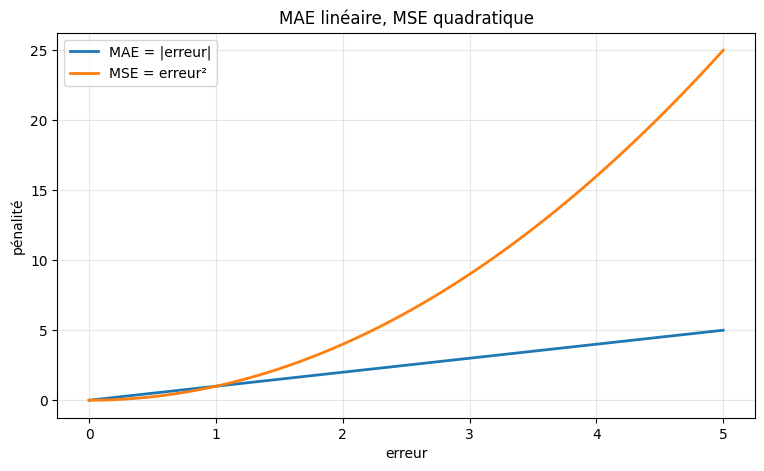

In [4]:
erreurs = np.linspace(0, 5, 100)
mae = erreurs # |e|
mse = erreurs**2 # e²
plt.figure(figsize=(9, 5))
plt.plot(erreurs, mae, label='MAE = |erreur|', lw=2)
plt.plot(erreurs, mse, label='MSE = erreur²', lw=2)
plt.xlabel('erreur')
plt.ylabel('pénalité')
plt.legend()
plt.title('MAE linéaire, MSE quadratique')
plt.grid(alpha=0.3)
plt.show()

La MAE est une droite : chaque unité d'erreur ajoute la même pénalité. La MSE est
une parabole : plus l'erreur grandit, plus chaque unité coûte cher.

La conséquence pratique. La MSE pousse le modèle à éviter les grosses
erreurs, quitte à en faire plusieurs petites. La MAE traite toutes les erreurs sur
un pied d'égalité.

Comme l'écrivait ton notebook : on utilise la MSE quand on accorde une importance croissante aux grandes erreurs, la MAE quand on leur accorde une importance proportionnelle.

Le choix dépend du problème. Prédire un délai de livraison : une erreur de 3 jours
n'est pas juste trois fois pire qu'une erreur d'un jour, elle est bien plus grave la MSE convient. Prédire une dépense moyenne : chaque euro d'écart compte pareil la MAE convient.

## 3. RMSE : revenir à l'échelle des données

La MSE a un défaut : son unité est le carré de celle des données. Si `y` est
en euros, la MSE est en euros². Impossible à interpréter.

La RMSE (*Root Mean Squared Error*) corrige ça en prenant la racine.

In [5]:
y = np.array([1, 2])
y_pred = np.array([5, 2]) # une erreur de 4, une de 0

print('MAE :', mean_absolute_error(y, y_pred))
print('MSE :', mean_squared_error(y, y_pred))
print('RMSE :', np.sqrt(mean_squared_error(y, y_pred)))

MAE : 2.0
MSE : 8.0
RMSE : 2.8284271247461903


La RMSE est dans la même unité que `y`. Elle se lit comme une erreur typique,
tout en gardant la propriété de la MSE : pénaliser les grosses erreurs.

C'est la métrique la plus courante en régression, parce qu'elle combine le
meilleur des deux : interprétable comme la MAE, sensible aux grosses erreurs comme
la MSE.

Note technique : les versions récentes de sklearn ont une fonction directe.

In [6]:
from sklearn.metrics import root_mean_squared_error
print('RMSE directe :', root_mean_squared_error(y, y_pred))

RMSE directe : 2.8284271247461903


`root_mean_squared_error` évite le `np.sqrt(mean_squared_error(...))` manuel. Sur
les versions plus anciennes, `mean_squared_error(y, y_pred, squared=False)`
faisait la même chose.

### Comparer MAE et RMSE

Sur les mêmes données, la RMSE est toujours supérieure ou égale à la MAE.
L'écart entre les deux est un indice.

In [7]:
y = np.array([1, 2])
y_pred = np.array([5, 2])
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f'MAE = {mae:.2f}')
print(f'RMSE = {rmse:.2f}')
print(f'écart : la RMSE est {rmse/mae:.1f}× la MAE')

MAE = 2.00
RMSE = 2.83
écart : la RMSE est 1.4× la MAE


Un grand écart RMSE/MAE signale que les erreurs sont inégales : quelques
grosses erreurs tirent la RMSE vers le haut. Si les deux sont proches, les erreurs
sont homogènes. C'est un diagnostic gratuit, obtenu en comparant deux chiffres.

## 4. Le piège des valeurs aberrantes

Voici le cas le plus instructif de ton notebook : une seule prédiction
catastrophique.

In [8]:
from sklearn.metrics import median_absolute_error

y = np.array([1, 2, 2, 3, 5, 2])
y_pred = np.array([5, 2, 2, 5, 7, 1000]) # la dernière est aberrante

print('MAE :', round(mean_absolute_error(y, y_pred), 2))
print('RMSE :', round(np.sqrt(mean_squared_error(y, y_pred)), 2))
print('Median Absolute Error :', median_absolute_error(y, y_pred))

MAE : 167.67
RMSE : 407.44
Median Absolute Error : 2.0


Regarde les trois chiffres. Une seule prédiction absurde (1000 au lieu de 2)
suffit à tout bouleverser sauf une métrique.

La MAE grimpe à 168 : la grosse erreur, divisée par 6, pèse encore lourd.

La RMSE explose à 407 : le carré de 998 est gigantesque, la racine reste
énorme. Elle est ultra-sensible aux aberrations.

La médiane des erreurs reste à 2 : elle ignore complètement l'aberration.

### Pourquoi la médiane résiste

C'est exactement la leçon du notebook 08. La médiane ne regarde que la valeurdu milieu, pas les extrêmes. Une  seule valeur monstrueuse ne la déplace pas,
alors qu'elle contamine toute moyenne.

In [9]:
erreurs = np.abs(y - y_pred)
print('les 6 erreurs :', sorted(erreurs))
print('moyenne des erreurs :', round(erreurs.mean(), 1), '-> la MAE')
print('médiane des erreurs :', np.median(erreurs), '-> insensible au 998')

les 6 erreurs : [np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(4), np.int64(998)]
moyenne des erreurs : 167.7 -> la MAE
médiane des erreurs : 2.0 -> insensible au 998


Quand utiliser quoi.

Si les valeurs aberrantes sont des erreurs de mesure à ignorer, la médiane des
erreurs donne une vision plus juste de la performance ordinaire.

Si elles sont des cas réels et importants une fraude, une pannen alors la
RMSE a raison de les mettre en avant : les rater serait grave.

Le réflexe, comme toujours : calculer les trois et comparer. Un grand écart
entre elles révèle la présence d'aberrations, information précieuse en soi.

## 5. Le R² : le coefficient de détermination

Le R² est la métrique renvoyée par `model.score` en régression. Il répond à une
question différente : quelle part de la variation le modèle explique-t-il ?

In [10]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
data = load_diabetes()
X = data.data
y = data.target
print('X :', X.shape)
print('y : de', y.min(), 'à', y.max())

X : (442, 10)
y : de 25.0 à 346.0


On utilise le jeu diabète, intégré à sklearn prédire la progression de la
maladie à partir de dix variables médicales.

In [11]:
model = LinearRegression()
model.fit(X, y)
print('R² :', round(model.score(X, y), 4))

R² : 0.5177


Un R² autour de 0,52. Comment le lire :

- R² = 1 : le modèle prédit parfaitement.
- R² = 0 : le modèle ne fait pas mieux que prédire la moyenne de `y` pour tout
  le monde.
- R² < 0 : le modèle fait pire que la moyenne oui, c'est possible.

Ici 0,52 signifie que le modèle explique environ la moitié de la variation de la
progression. Ni excellent ni nul et c'est justement ce qui rend ce jeu utile
pour comprendre les métriques : les erreurs sont réelles.

### Visualiser les erreurs

Comparons prédictions et réalité.

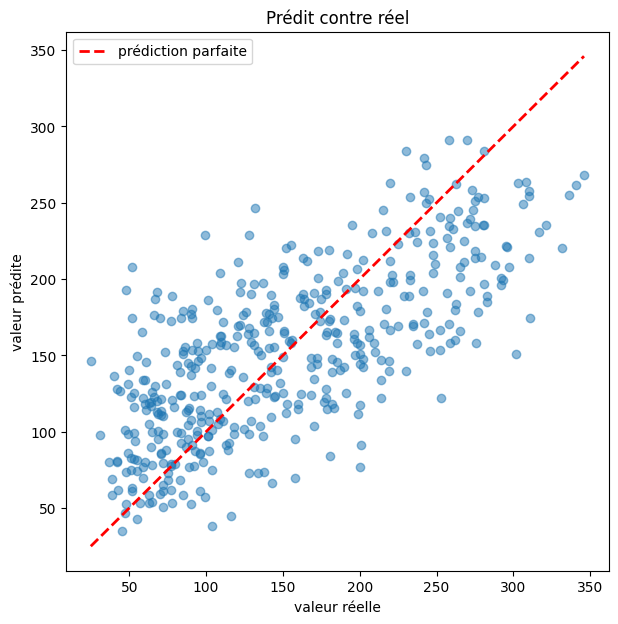

In [12]:
y_pred = model.predict(X)
plt.figure(figsize=(7, 7))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='prédiction parfaite')
plt.xlabel('valeur réelle')
plt.ylabel('valeur prédite')
plt.legend()
plt.title('Prédit contre réel')
plt.show()

Sur ce graphique, une prédiction parfaite placerait tous les points sur la
diagonale rouge. L'écart de chaque point à la droite est son erreur.

Le nuage est dispersé autour de la diagonale cohérent avec un R² de 0,52. Un
bon modèle serrerait les points contre la ligne.

### La distribution des erreurs

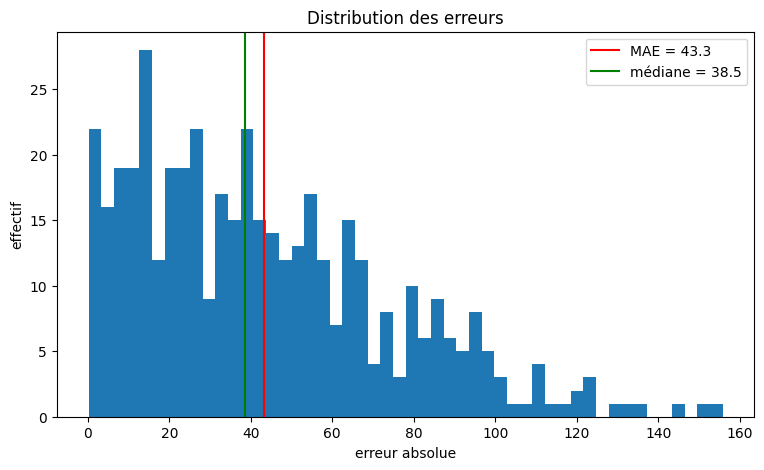

In [13]:
erreurs = np.abs(y - y_pred)
plt.figure(figsize=(9, 5))
plt.hist(erreurs, bins=50)
plt.axvline(erreurs.mean(), color='red', label=f'MAE = {erreurs.mean():.1f}')
plt.axvline(np.median(erreurs), color='green', label=f'médiane = {np.median(erreurs):.1f}')
plt.xlabel('erreur absolue')
plt.ylabel('effectif')
plt.legend()
plt.title('Distribution des erreurs')
plt.show()

L'histogramme montre où se concentrent les erreurs. La plupart sont petites, mais
la traîne à droite révèle quelques prédictions très mauvaises les patients dont
la progression est mal captée par un modèle linéaire.

C'est cette traîne qui fait diverger MAE et RMSE. Regarder la distribution, plutôt
qu'un seul chiffre, est le meilleur diagnostic la leçon du notebook 19 appliquée
aux erreurs.

## 6. Les métriques dans la validation croisée

`cross_val_score` accepte un argument `scoring` pour choisir la métrique.

In [14]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print('R² par pli :', scores.round(3))
print('R² moyen :', scores.mean().round(4))

R² par pli : [0.43  0.523 0.483 0.426 0.55 ]
R² moyen : 0.4823


### Le piège du « neg »

Pour une erreur, on écrit `neg_mean_squared_error`, avec un préfixe `neg`.
Pourquoi ce négatif ?

In [15]:
scores = cross_val_score(LinearRegression(), X, y, cv=5,
                         scoring='neg_mean_squared_error')
print('scores bruts :', scores.round(1))
print('négatifs !')

scores bruts : [-2779.9 -3028.8 -3237.7 -3008.7 -2910.2]
négatifs !


Les scores sont négatifs. La raison : `cross_val_score` maximise toujours pour lui, plus le score est haut, mieux c'est.

Or une erreur, on veut la minimiser. sklearn contourne ça en renvoyant
`-erreur` : maximiser `-MSE` revient à minimiser la MSE. C'est cohérent en
interne, mais il faut retirer le signe pour lire l'erreur réelle.

In [17]:
scores = cross_val_score(LinearRegression(), X, y, cv=5,
                         scoring='neg_mean_squared_error')
print('MSE moyenne :', round(-scores.mean(), 1))
print('RMSE :', round(np.sqrt(-scores.mean()), 2))

MSE moyenne : 2993.1
RMSE : 54.71


Le signe moins devant `scores.mean()` retrouve l'erreur positive.

### Le piège de l'accuracy

`accuracy` est une métrique de classification. L'utiliser en régression échoue.

In [18]:
try:
    cross_val_score(LinearRegression(), X, y, cv=3, scoring='accuracy')
except ValueError as e:
    print('ValueError :', str(e)[:95])

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py", line 227, in accuracy_score
    y_type, y_true, y_pred = _check_targets(y_true, y_pred)
                 

L'exactitude compte les prédictions exactement justes. En régression, prédire
34,7 pour une vraie valeur de 35,0 n'est jamais exact l'accuracy serait toujours
nulle. sklearn refuse donc cette combinaison.

### Voir toutes les métriques disponibles

In [19]:
from sklearn.metrics import get_scorer_names
noms = get_scorer_names()
print('Métriques de régression :')
print([m for m in noms if 'error' in m or 'r2' in m])

Métriques de régression :
['d2_absolute_error_score', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'r2']


In [20]:
noms

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

`get_scorer_names()` liste tous les noms utilisables dans `scoring`.

Toutes les métriques d'erreur y apparaissent en version `neg_`, pour la raison
vue plus haut.

## 7. Mémo

### Les métriques

| Métrique | Formule | Caractère |
|---|---|---|
| MAE | moyenne de \|erreur\| | linéaire, robuste |
| MSE | moyenne d'erreur² | punit les grosses erreurs, unité au carré |
| RMSE | racine de MSE | punit les grosses erreurs, bonne unité |
| Médiane des erreurs | médiane de \|erreur\| | ignore les aberrations |
| R² | part de variation expliquée | de −∞ à 1, sans unité |

### Choisir

- RMSE : le défaut, interprétable et sensible aux grosses erreurs.
- MAE : quand toutes les erreurs comptent également.
- Médiane des erreurs : quand il y a des aberrations à ignorer.
- R² : pour une vue globale, comparable entre problèmes.

### Dans cross_val_score

```python
cross_val_score(model, X, y, cv=5, scoring='r2')
cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `scoring='accuracy'` en régression | `ValueError` |
| Oublier le `neg` | métrique introuvable |
| Oublier de retirer le signe | erreur affichée en négatif |
| Se fier au seul R² | on rate les grosses erreurs |
| MSE lue telle quelle | unité au carré, ininterprétable |
| Modèle sans parenthèses | `TypeError` |

## 8. Exercices

**Exercice 1**

Sur le jeu diabète, compare `LinearRegression` et `DecisionTreeRegressor` selon
trois métriques : R², MAE et RMSE, en validation croisée. Un modèle peut-il être
meilleur sur une métrique et moins bon sur une autre ? Que conclus-tu ?

**Exercice 2**

Reprends une prédiction propre, puis remplace volontairement une seule vraie
valeur par une aberration énorme. Recalcule MAE, RMSE et médiane des erreurs
avant et après. Laquelle bouge le plus, laquelle ne bouge pas, et pourquoi ?

**Exercice 3**

Ce code veut afficher l'erreur quadratique moyenne d'un modèle en validation
croisée :

```python
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print('MSE :', scores.mean())
```

Il affiche un nombre négatif, ce qui n'a pas de sens pour une erreur. Explique
pourquoi sklearn renvoie du négatif, corrige pour afficher la vraie MSE, puis
transforme-la en RMSE pour qu'elle soit dans l'unité des données.

## Pour continuer

Le notebook suivant ouvre le prétraitement : normaliser les variables, encoder les
catégories. Ces métriques resteront tes juges après chaque transformation, tu
mesureras si le modèle s'améliore, avec la RMSE ou le R².

On y verra aussi comment le choix des variables et leur mise à l'échelle peuvent
faire chuter la RMSE bien plus qu'un changement de modèle.

In [21]:
# Exercice 1

In [22]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

X, y = load_diabetes(return_X_y=True)

modeles = {
    'Régression linéaire': LinearRegression(),
    'Arbre de décision':   DecisionTreeRegressor(random_state=0),
}

print(f'{"modèle":<22} {"R²":>7} {"MAE":>8} {"RMSE":>8}')
print('-' * 47)

for nom, model in modeles.items():
    r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    mae = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error').mean()
    mse = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error').mean()
    rmse = np.sqrt(mse)
    print(f'{nom:<22} {r2:>7.3f} {mae:>8.2f} {rmse:>8.2f}')

modèle                      R²      MAE     RMSE
-----------------------------------------------
Régression linéaire      0.482    44.28    54.71
Arbre de décision       -0.096    62.67    79.82


In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# deux modèles au comportement différent sur les extrêmes
for model in [KNeighborsRegressor(n_neighbors=1), KNeighborsRegressor(n_neighbors=20)]:
    mae = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error').mean()
    rmse = np.sqrt(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error').mean())
    print(f'k={model.n_neighbors:<3} MAE={mae:.2f}  RMSE={rmse:.2f}  écart={rmse/mae:.2f}')

k=1   MAE=56.07  RMSE=73.80  écart=1.32
k=20  MAE=45.63  RMSE=56.37  écart=1.24


In [24]:
# Exercice 2

In [26]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error

# Des prédictions propres
y_reel = np.array([10, 12, 11, 13, 9, 14, 10, 11])
y_pred = np.array([10, 13, 11, 12, 10, 13, 11, 12])

print(' AVANT (données propres) ')
print('MAE :', round(mean_absolute_error(y_reel, y_pred), 2))
print('RMSE :', round(np.sqrt(mean_squared_error(y_reel, y_pred)), 2))
print('Médiane des erreurs :', median_absolute_error(y_reel, y_pred))

 AVANT (données propres) 
MAE : 0.75
RMSE : 0.87
Médiane des erreurs : 1.0


In [27]:
y_aberrant = y_reel.copy()
y_aberrant[3] = 500 # au lieu de 13

print(' APRÈS (une valeur passée à 500) ')
print('MAE :', round(mean_absolute_error(y_aberrant, y_pred), 2))
print('RMSE :', round(np.sqrt(mean_squared_error(y_aberrant, y_pred)), 2))
print('Médiane des erreurs :', median_absolute_error(y_aberrant, y_pred))

 APRÈS (une valeur passée à 500) 
MAE : 61.62
RMSE : 172.54
Médiane des erreurs : 1.0


In [28]:
erreurs_avant = np.sort(np.abs(y_reel - y_pred))
erreurs_apres = np.sort(np.abs(y_aberrant - y_pred))

print('erreurs triées avant :', erreurs_avant)
print('erreurs triées après :', erreurs_apres)

erreurs triées avant : [0 0 1 1 1 1 1 1]
erreurs triées après : [  0   0   1   1   1   1   1 488]


In [29]:
# Exercice 3

In [30]:
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print('MSE :', scores.mean())

MSE : -3177.6867141853936


In [32]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
X, y = load_diabetes(return_X_y=True)
model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
mse = -scores.mean() # le signe moins retrouve l'erreur positive
print('MSE :', round(mse, 2))

MSE : 2993.08


In [33]:
rmse = np.sqrt(mse)
print('RMSE :', round(rmse, 2))

RMSE : 54.71


In [34]:
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print(f'score brut (négatif) : {scores.mean():.1f}')
print(f'MSE (signe retiré) : {-scores.mean():.1f}')
print(f'RMSE (racine) : {np.sqrt(-scores.mean()):.1f}')

score brut (négatif) : -2993.1
MSE (signe retiré) : 2993.1
RMSE (racine) : 54.7
